<a href="https://colab.research.google.com/github/intisariapps-com/Intisari-AutoCut-Android/blob/main/AutoCut_Studio_WebUI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


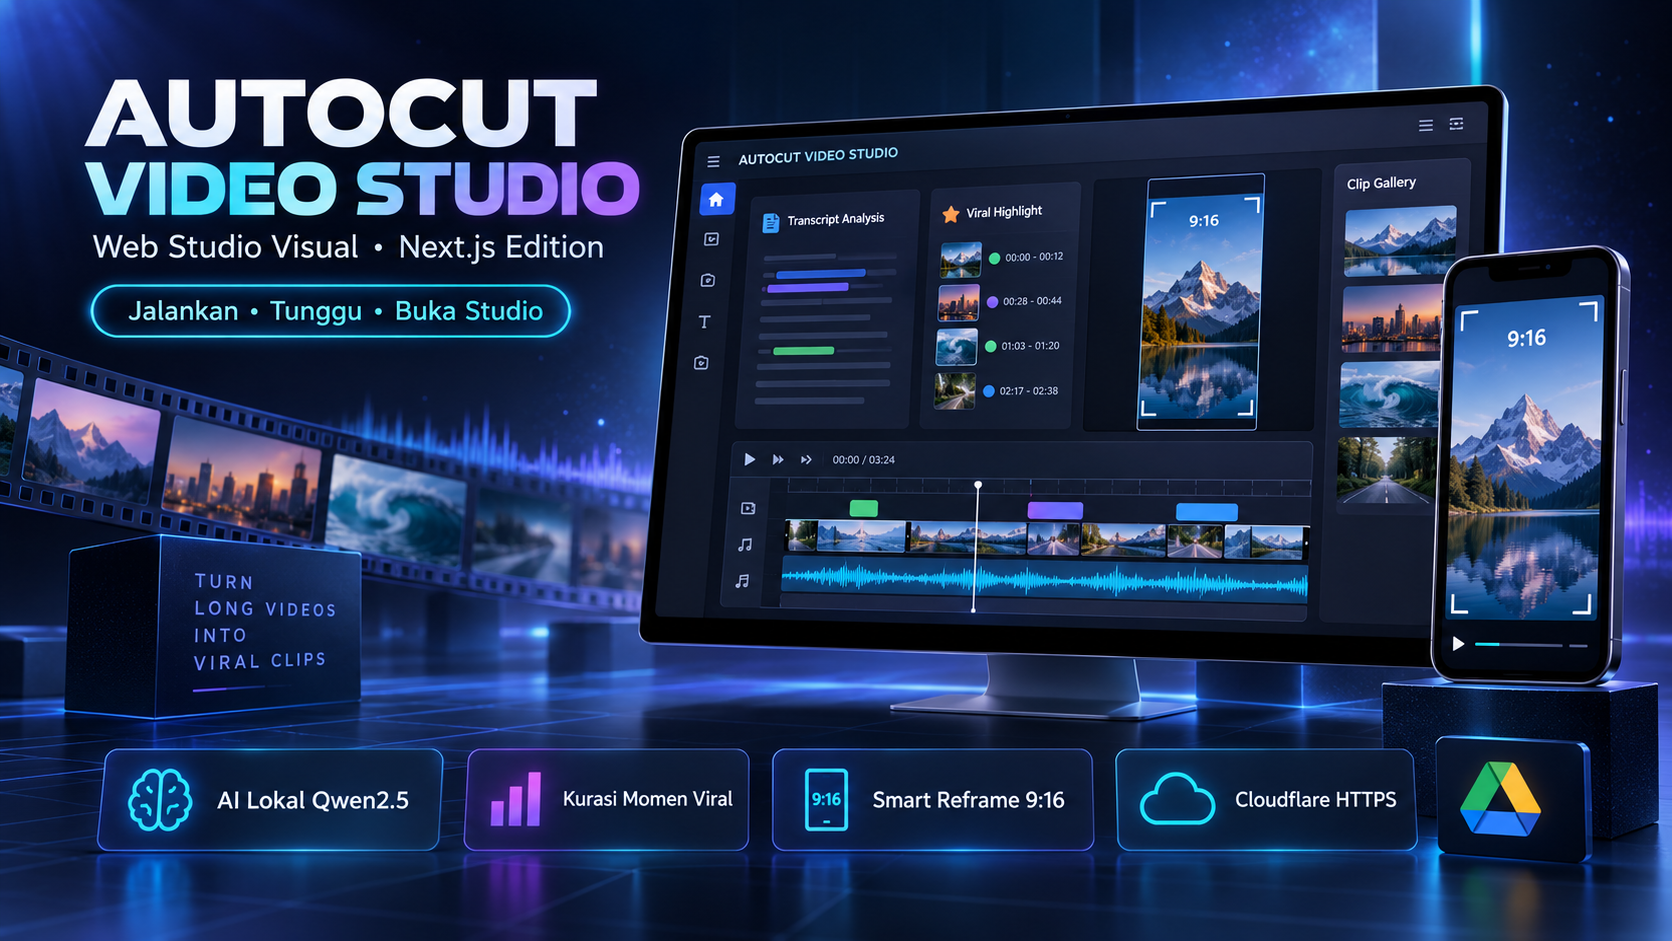


In [ ]:
"""
🎬 AUTOCUT VIDEO STUDIO — WEB STUDIO VISUAL NEXT.JS (V1.8.0)
Hak Cipta (C) 2026 IntisariApps.com. Seluruh hak cipta dilindungi.
Menyajikan Antarmuka Visual Next.js + Backend Kurasi AI Qwen2.5 & Render GPU Colab.
"""

# @title ⚙️ PUSAT KENDALI ENGINE RENDERING COLAB
# @markdown Atur parameter sesi Colab di bawah ini:
AUTO_SHUTDOWN_MINUTES = 10  # @param [0, 5, 10, 15, 30] {type:"raw"}
GOOGLE_DRIVE_SYNC = "oauth_persistent"  # @param ["oauth_persistent", "native_mount", "oauth_api", "disabled"]
GDRIVE_FOLDER_NAME = "AutoCut_Videos"  # @param {type:"string"}
GDRIVE_TOKEN_JSON = ""  # @param {type:"string"}
GROQ_API_KEY = ""  # @param {type:"string"}
HF_TOKEN = ""  # @param {type:"string"}

import os
import sys
import time
import json
import subprocess
import zipfile
import sysconfig
import urllib.request

# Simpan API Key & Kredensial ke environment jika diisi
if "GROQ_API_KEY" in globals() and GROQ_API_KEY and GROQ_API_KEY.strip():
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY.strip()
if "HF_TOKEN" in globals() and HF_TOKEN and HF_TOKEN.strip():
    os.environ["HF_TOKEN"] = HF_TOKEN.strip()

# Muat kredensial R2 dari Colab Secrets jika tersedia
try:
    from google.colab import userdata
    for secret_key in ["R2_ACCOUNT_ID", "R2_ACCESS_KEY_ID", "R2_SECRET_ACCESS_KEY", "R2_BUCKET_NAME", "R2_PUBLIC_DOMAIN", "R2_ENDPOINT_URL"]:
        val = userdata.get(secret_key)
        if val:
            os.environ[secret_key] = str(val).strip()
except Exception:
    pass

# Penanganan integrasi Google Drive
if GOOGLE_DRIVE_SYNC == "oauth_persistent":
    token_json = GDRIVE_TOKEN_JSON.strip() if ("GDRIVE_TOKEN_JSON" in globals() and GDRIVE_TOKEN_JSON) else ""
    if not token_json:
        try:
            from google.colab import userdata
            token_json = userdata.get("GDRIVE_TOKEN_JSON") or ""
        except Exception:
            token_json = ""
    if token_json:
        os.environ["GDRIVE_TOKEN_JSON"] = token_json
elif GOOGLE_DRIVE_SYNC == "native_mount":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e_mnt:
        print(f"⚠️ Google Drive native mount: {e_mnt}", flush=True)

print("=" * 80)
# Dedicated Video Gateway R2 (video.intisariapps.com) aktif secara otomatis (Zero-Secret).
print("🎬 MEMULAI AUTOCUT VIDEO STUDIO (NEXT.JS & AI LOCAL GGUF)")
print("=" * 80)

# 0. Pastikan binary cloudflared tersedia untuk terowongan fallback instan
if not os.path.exists("/usr/local/bin/cloudflared"):
    try:
        subprocess.run(["wget", "-q", "-O", "/usr/local/bin/cloudflared", "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64"], check=False)
        subprocess.run(["chmod", "+x", "/usr/local/bin/cloudflared"], check=False)
    except Exception:
        pass

# 1. Instal dependensi sistem dasar (Gradio, FastAPI, MediaPipe, llama-cpp-python)
print("📦 [1/4] Memeriksa & memasang dependensi (FastAPI, Uvicorn, MediaPipe, yt-dlp)...", flush=True)
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "fastapi", "uvicorn[standard]", "python-multipart", "mediapipe", "requests", "qrcode", "pydantic", "yt-dlp"], check=False)

has_gpu = False
try:
    has_gpu = subprocess.run(["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL).returncode == 0
except Exception:
    has_gpu = False

if has_gpu:
    print("⚡ [1/4] Akselerator GPU T4 aktif! Memasang llama-cpp-python CUDA...", flush=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "llama-cpp-python", "--prefer-binary", "--extra-index-url", "https://abetlen.github.io/llama-cpp-python/whl/cu122"], check=False)
else:
    print("💻 [1/4] Mode CPU terdeteksi. Memeriksa binary wheel llama-cpp-python (anti-hang)...", flush=True)
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--only-binary=:all:", "--extra-index-url", "https://abetlen.github.io/llama-cpp-python/whl/cpu", "llama-cpp-python"], check=False, timeout=35)
    except Exception:
        print("ℹ️ [1/4] Binary wheel CPU dilewati, menggunakan fallback AI Cloud.", flush=True)

# 2. Pra-unduh model AI Lokal resmi Qwen2.5 GGUF ke disk NVMe Colab (Eager Warm-Up)
model_cache_dir = "/content/models"
model_target_file = os.path.join(model_cache_dir, "qwen2.5-1.5b-instruct-q4_k_m.gguf")
if not os.path.exists(model_target_file) or os.path.getsize(model_target_file) < 900 * 1024 * 1024:
    os.makedirs(model_cache_dir, exist_ok=True)
    print("🧠 [2/4] Mengunduh model AI resmi Qwen2.5-1.5B GGUF (~1.1 GB)...", flush=True)
    gguf_dl_url = "https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct-GGUF/resolve/main/qwen2.5-1.5b-instruct-q4_k_m.gguf"
    try:
        urllib.request.urlretrieve(gguf_dl_url, model_target_file + ".part")
        os.replace(model_target_file + ".part", model_target_file)
        print("✅ Model AI Qwen2.5 siap di disk Colab!", flush=True)
    except Exception as e_gguf_dl:
        print(f"⚠️ Pra-unduh model AI: {e_gguf_dl}", flush=True)
else:
    print("✅ [2/4] Model AI Qwen2.5 sudah tersedia di disk NVMe Colab.", flush=True)

# 3. Unduh & pasang modul engine terenkripsi resmi + Next.js Web Studio
print("🔐 [3/4] Mengunduh modul engine & Web Studio: autocut_video_engine.zip...")
pkg_url = f"https://raw.githubusercontent.com/intisariapps-com/Intisari-AutoCut-Android/main/autocut_video_engine.zip?t={int(time.time())}"
pkg_local = "/tmp/autocut_video_engine.zip"
try:
    subprocess.run(["wget", "-q", "--no-cache", "--no-cookies", "-O", pkg_local, pkg_url], check=True)
except Exception:
    urllib.request.urlretrieve(pkg_url, pkg_local)

pkg_size_kb = round(os.path.getsize(pkg_local) / 1024, 1) if os.path.exists(pkg_local) else 0.0
print(f"📦 Paket Biner Terpasang: autocut_video_engine.zip ({pkg_size_kb} KB)")
site_pkg = sysconfig.get_paths()["purelib"]
with zipfile.ZipFile(pkg_local, "r") as zf:
    zf.extractall(site_pkg)

# Bersihkan cache registri modul Python
for mod in list(sys.modules.keys()):
    if "autocut_video_engine" in mod or "pyarmor" in mod:
        del sys.modules[mod]

import autocut_video_engine
from autocut_video_engine.server import run_studio_server
engine_ver = getattr(autocut_video_engine, "__version__", "1.8.0")
print(f"🚀 [4/4] Modul Terverifikasi: AutoCut Video Studio Engine v{engine_ver} (Next.js SPA Embedded)")

# 4. Jalankan Web Studio & Server GPU Colab via Single-Tunnel Cloudflare
run_studio_server(
    auto_shutdown_minutes=AUTO_SHUTDOWN_MINUTES,
    mode="webui",
    wait_forever=True
)
